# Contract Review Pipeline — Evaluation Analysis
Reads `output/eval/results.json` produced by `python scripts/evaluate.py --quick`.

In [1]:
import json, math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

results_path = Path("../output/eval/results.json")
with open(results_path) as f:
    results = json.load(f)
print("Loaded results for stages:", list(results.keys()))

Loaded results for stages: ['clause_discovery', 'retrieval', 'interpretation', 'risk_rating']


## Stage 1 — Clause Discovery

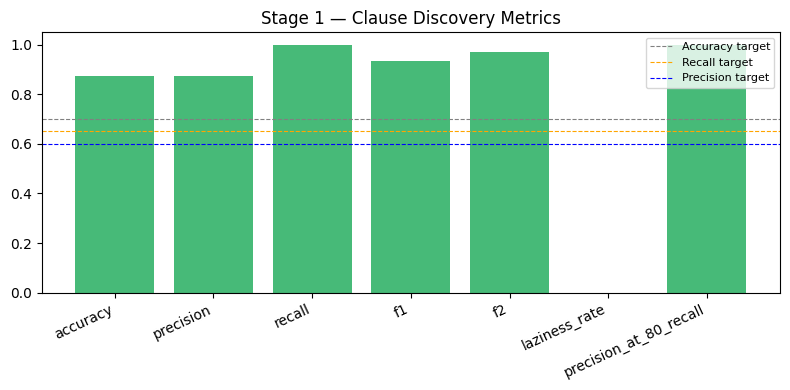

Confusion: {'tp': 7, 'fp': 1, 'fn': 0, 'tn': 0}


In [2]:
cd = results["clause_discovery"]
metrics = {k: v for k, v in cd.items() if isinstance(v, float)}
targets = {"accuracy": 0.70, "precision": 0.60, "recall": 0.65}

fig, ax = plt.subplots(figsize=(8, 4))
names = list(metrics.keys())
vals  = list(metrics.values())
colors = ["#27ae60" if vals[i] >= targets.get(names[i], 0) else "#c0392b"
          for i in range(len(names))]
ax.bar(names, vals, color=colors, alpha=0.85)
ax.axhline(0.70, color="gray", linestyle="--", linewidth=0.8, label="Accuracy target")
ax.axhline(0.65, color="orange", linestyle="--", linewidth=0.8, label="Recall target")
ax.axhline(0.60, color="blue", linestyle="--", linewidth=0.8, label="Precision target")
ax.set_ylim(0, 1.05)
ax.set_title("Stage 1 — Clause Discovery Metrics")
ax.legend(fontsize=8)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

confusion = {k: cd.get(k, 0) for k in ("tp","fp","fn","tn")}
print("Confusion:", confusion)

## Stage 2 — Retrieval Quality

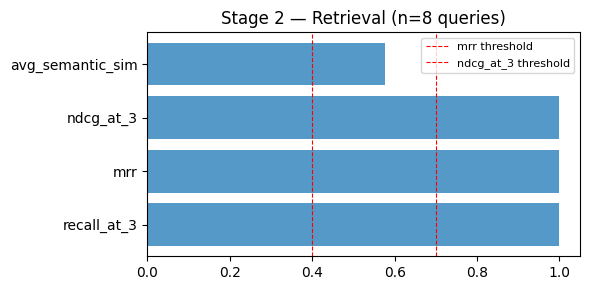

In [3]:
ret = results.get("retrieval", {})
retrieval_metrics = {k: v for k, v in ret.items() if isinstance(v, float)}
ref_lines = {"mrr": 0.40, "ndcg_at_3": 0.70}

fig, ax = plt.subplots(figsize=(6, 3))
names = list(retrieval_metrics.keys())
vals  = list(retrieval_metrics.values())
ax.barh(names, vals, color="#2980b9", alpha=0.8)
for name, threshold in ref_lines.items():
    if name in names:
        ax.axvline(threshold, color="red", linestyle="--", linewidth=0.8, label=f"{name} threshold")
ax.set_xlim(0, 1.05)
ax.set_title(f"Stage 2 — Retrieval (n={ret.get('n_queries', '?')} queries)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Stage 4 — Risk Distribution

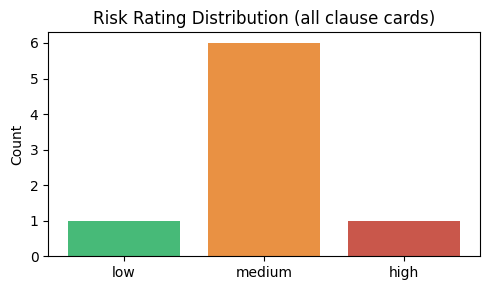

Distribution: {'high': 1, 'medium': 6, 'low': 1}
Risk distribution check (not all same): PASS


In [4]:
# Reload raw pipeline JSONs to get per-card risk ratings
import os
json_dir = Path("../output/json")
all_ratings = []
for f in json_dir.glob("*.json"):
    data = json.loads(f.read_text())
    for card in data.get("clause_cards", []):
        rating = card.get("llm_generated_risk_rating")
        if rating:
            all_ratings.append(rating)

from collections import Counter
counts = Counter(all_ratings)
labels = ["low", "medium", "high"]
vals = [counts.get(l, 0) for l in labels]
colors_risk = ["#27ae60", "#e67e22", "#c0392b"]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, vals, color=colors_risk, alpha=0.85)
ax.set_title("Risk Rating Distribution (all clause cards)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Distribution:", dict(counts))
unique_ratings = len([v for v in vals if v > 0])
print("Risk distribution check (not all same):", "PASS" if unique_ratings > 1 else "FAIL")